In [1]:
import pandas as pd
import numpy as np
import duckdb
import seaborn as sns
from scipy.stats import chisquare, chi2, chi2_contingency, ncx2
from scipy.optimize import brentq

import sys
import os
sys.path.append(os.path.abspath(os.path.join('..'))) 

from src.cleaning import fix_date_column
from src.statistical_tests import *

In [2]:
experiment = pd.read_csv("../data/part_b_dataset.csv")
experiment.head()

,userid,country,day_exposed_to_ad,treatment,signed_up_metal,signed_up_standard
0,e0912256-b48a-45c0-afec-23350d341abd,Spain,2017-03-01,Standard,0,1
1,321c18f1-c58e-488d-a60a-462dfc9d38aa,Italy,2017-03-10,Standard,0,0
2,3d03c163-d14b-49da-873a-a54cc3b400e3,Italy,2017-03-24,Metal,0,1
3,3acb5a84-4375-405b-9a8b-bfb8979ab9bc,Spain,2017-03-06,Standard,0,1
4,1b488764-6874-4483-8e70-815feb07b154,Italy,2017-03-03,Metal,0,0


In [3]:
date_clean = fix_date_column(experiment, 'day_exposed_to_ad')

[fix_date_column] dropped 0 row(s); 5000/5000 remain.


In [4]:
duckdb.query(""" 
    select 
        userid 
    from date_clean 
    group by 1 
    having count(*) > 1
""").to_df()

,userid


In [5]:
duckdb.query(""" 
    select 
        treatment
        , signed_up_metal
        , signed_up_standard
        , count(distinct userid) as user_count 
        , count(distinct userid) / sum(count(distinct userid)) over(partition by treatment) as pct
    from date_clean
    group by 1,2,3
    order by 1,2,3
""").to_df()

,treatment,signed_up_metal,signed_up_standard,user_count,pct
0,Metal,0,0,1958,0.794965
1,Metal,0,1,341,0.138449
2,Metal,1,0,164,0.066585
3,Standard,0,0,1979,0.780055
4,Standard,0,1,388,0.152937
5,Standard,1,0,170,0.067008


In [6]:
duckdb.query(""" 
    select 
        treatment,
        count(distinct userid) AS user_count,
        round(count(distinct userid) / sum(count(distinct userid)) over (), 2) as pct
    from date_clean
    group by 1
""").to_df()

,treatment,user_count,pct
0,Standard,2537,0.51
1,Metal,2463,0.49


In [7]:
duckdb.query(""" 
    select 
        treatment,
        country,
        count(distinct userid) AS user_count,
        round(count(distinct userid) / sum(count(distinct userid)) over (partition by country), 2) as pct
    from date_clean
    group by 1,2
""").to_df()

,treatment,country,user_count,pct
0,Metal,Spain,1216,0.49
1,Standard,Spain,1254,0.51
2,Metal,Italy,1247,0.49
3,Standard,Italy,1283,0.51


In [8]:
duckdb.query("""
    with base as (
        select
            treatment
            , country
            , count(distinct userid) AS exposed 
            , count(case when signed_up_metal = 1 then userid end) AS metal_signups
            , count(case when signed_up_standard = 1 then userid end) AS standard_signups
            , count(CASE WHEN signed_up_metal + signed_up_standard >= 1 THEN userid END) AS any_signups
        from date_clean
        group by 1,2
    )
             
    , ratios as (                
        select *
            , round(metal_signups * 1.0 / exposed, 4) as metal_signup_rate
            , round(standard_signups * 1.0 / exposed, 4) as standard_signup_rate
            , round(any_signups * 1.0 / exposed, 4) as any_signup_rate     
        from base
    )
             
    select * from ratios
    """
).to_df()

,treatment,country,exposed,metal_signups,standard_signups,any_signups,metal_signup_rate,standard_signup_rate,any_signup_rate
0,Metal,Spain,1216,84,170,254,0.0691,0.1398,0.2089
1,Standard,Spain,1254,89,186,275,0.0710,0.1483,0.2193
2,Standard,Italy,1283,81,202,283,0.0631,0.1574,0.2206
3,Metal,Italy,1247,80,171,251,0.0642,0.1371,0.2013


In [9]:
duckdb.query(""" 
    select *
        , metal_user_count / user_count as metal_user_pct
        , standard_user_count / user_count as standard_user_pct
    from (   
        select 
            dayofweek(day_exposed_to_ad) as day_of_week
            , count(distinct userid) as user_count
            , count(distinct case when treatment = 'Metal' then userid end) as metal_user_count
            , count(distinct case when treatment = 'Standard' then userid end) as standard_user_count
        from date_clean
        group by 1
        order by 1
    ) x
    """
).to_df()

,day_of_week,user_count,metal_user_count,standard_user_count,metal_user_pct,standard_user_pct
0,0,672,314,358,0.467262,0.532738
1,1,654,332,322,0.507645,0.492355
2,2,645,323,322,0.500775,0.499225
3,3,845,417,428,0.493491,0.506509
4,4,803,408,395,0.508095,0.491905
5,5,725,357,368,0.492414,0.507586
6,6,656,312,344,0.475610,0.524390


In [10]:
print(f"""{date_clean["day_exposed_to_ad"].min()} and {date_clean["day_exposed_to_ad"].max()}""")

2017-03-01 00:00:00 and 2017-03-31 00:00:00


<Axes: xlabel='day_exposed_to_ad', ylabel='userid'>

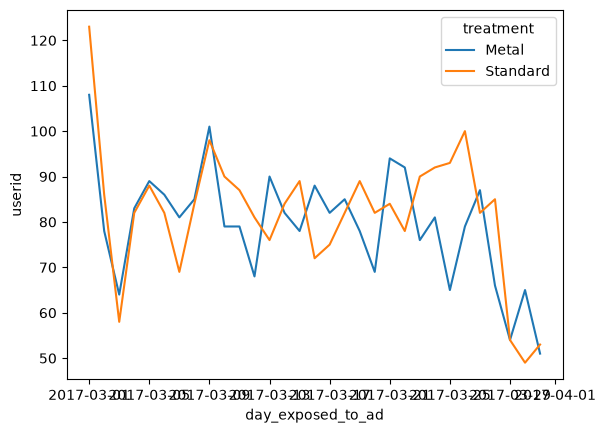

In [11]:
sns.lineplot(
    data=date_clean.groupby(["day_exposed_to_ad", "treatment"])[["userid"]].count(), 
    x="day_exposed_to_ad", 
    y="userid", 
    hue="treatment"
)

In [12]:
# sample ratio mismatch

srm = date_clean.groupby("treatment")["userid"].nunique().reset_index(name="n")

n_total = srm["n"].sum()
stat, p = chisquare(f_obs=srm["n"].values, f_exp=[n_total/2, n_total/2])
print(f"\nSRM Test: chi2={stat:.4f}, p={p:.4f}")
print("is there a mismatch in sample ratio?", "yes" if p < 0.01 else "no!")


SRM Test: chi2=1.0952, p=0.2953
is there a mismatch in sample ratio? no!


In [13]:
df = date_clean.copy()

df["any_signup"] = ((df["signed_up_metal"] + df["signed_up_standard"]) >= 1).astype(int)

df["no_signup"] = ((df["signed_up_metal"] + df["signed_up_standard"]) == 0).astype(int)

df["target_signup"] = df.apply(
    lambda r: r["signed_up_metal"] if r["treatment"] == "Metal" else r["signed_up_standard"],
    axis=1
)

df["cross_signup"] = df.apply(
    lambda r: r["signed_up_standard"] if r["treatment"] == "Metal" else r["signed_up_metal"],
    axis=1
)

metric_summary = df.groupby("treatment")[["no_signup", "any_signup", "target_signup", "cross_signup"]].mean().round(4)
metric_summary["n"] = df.groupby("treatment")["userid"].count()

metric_summary

,no_signup,any_signup,target_signup,cross_signup,n
treatment,,,,,
Metal,0.7950,0.2050,0.0666,0.1384,2463
Standard,0.7801,0.2199,0.1529,0.0670,2537


In [14]:
chi2_stat_any, p_value_any, dof_any = chi2_test(df, outcome = "any_signup", group_col="treatment")

Chi2: 1.5718, dof: 1, p-value: 0.20994, Cohen's w: 0.0177
Fail to reject the null hypothesis: no significant association between 'any_signup' and 'treatment'.


In [15]:
chi2_power_report(chi2_stat = chi2_stat_any, dof = dof_any, power=0.80, N = len(df))


        Inconclusive (power=0.24): not significant, but observed w=0.018 is below the MDE w=0.040, 
        so the test was too weak to detect it. Absence of evidence is not evidence of absence. Need ~24967 total for power=0.8.


,question,value
0,observed effect (Cohen's w),0.017730
1,MDE: smallest detectable w at N=5000,0.039620
2,power at the observed effect,0.240675
3,N needed for power=0.8,24967.353914


In [16]:
chi2_stat, p_value, dof = chi2_test(df, outcome = ["no_signup", "target_signup", "cross_signup"], group_col="treatment")

Chi2: 147.1707, dof: 2, p-value: 0.00000, Cohen's w: 0.1716
Reject the null hypothesis: '['no_signup', 'target_signup', 'cross_signup']' is associated with 'treatment'.


In [17]:
chi2_power_report(chi2_stat = chi2_stat, dof = dof, power=0.80, N = len(df))


        Significant and well-powered (power=1.00): observed w=0.172 is above the MDE w=0.044. 
        Reliable association, trust the result.


,question,value
0,observed effect (Cohen's w),0.171564
1,MDE: smallest detectable w at N=5000,0.043897
2,power at the observed effect,1.000000
3,N needed for power=0.8,327.330417


In [18]:
chi2_residuals(df, outcome = ["no_signup", "target_signup", "cross_signup"], group_col="treatment")

,no_signup,target_signup,cross_signup
treatment,,,
Metal,1.288293,-9.740769,8.337547
Standard,-1.288293,9.740769,-8.337547
